# Modelo de Previsão do Índice de Ilha de Calor Urbana (UHI)

Este notebook demonstra o processo de desenvolvimento de um modelo para prever o Índice de Ilha de Calor Urbana (UHI) utilizando dados de satélite como features, sem usar coordenadas geográficas como preditores.


## 1. Configuração do Ambiente e Bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configurações visuais
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
warnings.filterwarnings('ignore')

# Configurações para visualização
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

## 2. Carregamento e Exploração dos Dados

Vamos carregar o conjunto de dados de treinamento e explorar sua estrutura:

In [2]:
# Carregar os dados de treinamento
df_train = pd.read_csv('dataset/training_data.csv')

# Exibir as primeiras linhas
print("Primeiras linhas do conjunto de dados:")
df_train.head()

Primeiras linhas do conjunto de dados:


,Longitude,Latitude,datetime,UHI Index
0,-73.909167,40.813107,24-07-2021 15:53,1.030289
1,-73.909187,40.813045,24-07-2021 15:53,1.030289
2,-73.909215,40.812978,24-07-2021 15:53,1.023798
3,-73.909242,40.812908,24-07-2021 15:53,1.023798
4,-73.909257,40.812845,24-07-2021 15:53,1.021634


In [3]:
# Informações sobre as colunas
print("\nInformações sobre o conjunto de dados:")
df_train.info()


Informações sobre o conjunto de dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11229 entries, 0 to 11228
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Longitude  11229 non-null  float64
 1   Latitude   11229 non-null  float64
 2   datetime   11229 non-null  object 
 3   UHI Index  11229 non-null  float64
dtypes: float64(3), object(1)
memory usage: 351.0+ KB


In [4]:
# Estatísticas descritivas
print("\nEstatísticas descritivas:")
df_train.describe()


Estatísticas descritivas:


,Longitude,Latitude,UHI Index
count,11229.000000,11229.000000,11229.000000
mean,-73.933927,40.808800,1.000001
std,0.028253,0.023171,0.016238
min,-73.994457,40.758792,0.956122
25%,-73.955703,40.790905,0.988577
50%,-73.932968,40.810688,1.000237
75%,-73.909647,40.824515,1.011176
max,-73.879458,40.859497,1.046036


## 3. Pré-processamento dos Dados

In [5]:
# Remover a coluna de timestamp
df_train = df_train.drop('datetime', axis=1)

# Verificar as colunas restantes
print("Colunas após remoção do timestamp:")
df_train.columns

Colunas após remoção do timestamp:


Index(['Longitude', 'Latitude', 'UHI Index'], dtype='object')

In [6]:
# Verificar valores nulos
print("\nValores nulos por coluna:")
df_train.isnull().sum()


Valores nulos por coluna:


Longitude    0
Latitude     0
UHI Index    0
dtype: int64

## 4. Análise Exploratória dos Dados (EDA)

Vamos visualizar a distribuição do Índice UHI e explorar sua relação espacial:

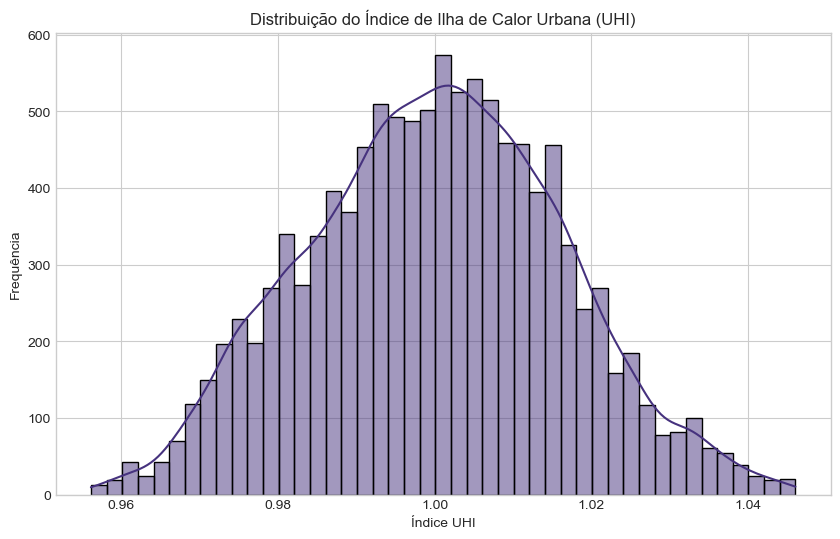

In [7]:
# Histograma do Índice UHI
plt.figure(figsize=(10, 6))
sns.histplot(df_train['UHI Index'], kde=True)
plt.title('Distribuição do Índice de Ilha de Calor Urbana (UHI)')
plt.xlabel('Índice UHI')
plt.ylabel('Frequência')
plt.grid(True)
plt.show()

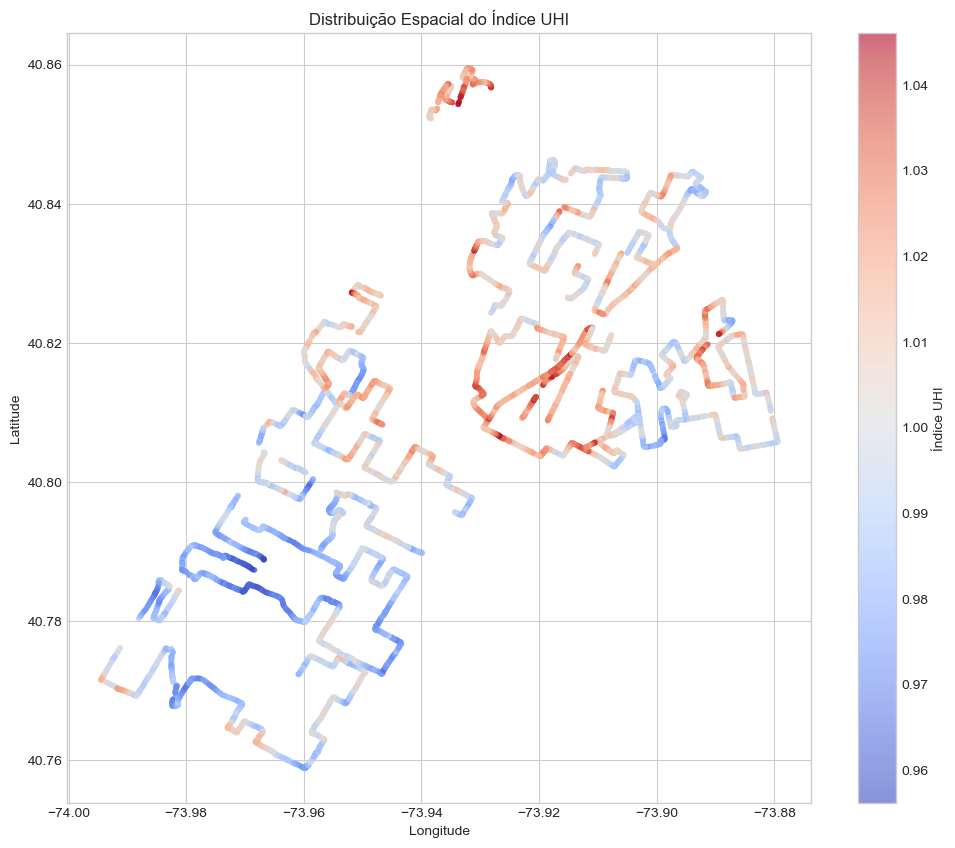

In [8]:
# Scatterplot das localizações coloridas pelo Índice UHI
plt.figure(figsize=(12, 10))
scatter = plt.scatter(df_train['Longitude'], df_train['Latitude'], 
                    c=df_train['UHI Index'], cmap='coolwarm', 
                    alpha=0.6, s=10)
plt.colorbar(scatter, label='Índice UHI')
plt.title('Distribuição Espacial do Índice UHI')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

In [9]:
# Estatísticas por quartis do Índice UHI
print("Estatísticas por quartis do Índice UHI:")
df_train['UHI_quartil'] = pd.qcut(df_train['UHI Index'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
df_train.groupby('UHI_quartil')['UHI Index'].describe()

Estatísticas por quartis do Índice UHI:


,count,mean,std,min,25%,50%,75%,max
UHI_quartil,,,,,,,,
Q1,2814.0,0.979043,0.006970,0.956122,0.974633,0.980403,0.984851,0.988577
Q2,2805.0,0.994757,0.003277,0.988697,0.991943,0.994948,0.997713,1.000237
Q3,2803.0,1.005586,0.003168,1.000358,1.002762,1.005406,1.008291,1.011176
Q4,2807.0,1.020676,0.007676,1.011296,1.014782,1.018629,1.025000,1.046036


## 5. Extração de Dados de Satélite

Agora vamos configurar o ambiente para extrair dados de satélite do Microsoft Planetary Computer. Precisaremos dos dados do Sentinel-2 e Landsat que correspondam temporalmente à coleta dos dados UHI (24 de julho de 2021).


In [10]:
import planetary_computer
from pystac_client import Client
from odc.stac import stac_load
from datetime import datetime, timedelta
import pystac_client

# Verificar a versão do stackstac para debugging
import importlib.metadata
print(f"Versão do stackstac: {importlib.metadata.version('stackstac')}")

Versão do stackstac: 0.5.1


In [18]:
# Inicializar o cliente Planetary Computer
pc = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace
)

# Definir intervalo de tempo para busca de imagens
# Podemos buscar imagens alguns dias antes da coleta para garantir cobertura de nuvens mínima
data_coleta = "2021-07-24"
data_inicio = (datetime.strptime(data_coleta, "%Y-%m-%d") - timedelta(days=30)).strftime("%Y-%m-%d")
data_fim = (datetime.strptime(data_coleta, "%Y-%m-%d") + timedelta(days=30)).strftime("%Y-%m-%d")

# Extrair coordenadas para definir a área de busca
min_lon = df_train['Longitude'].min()
max_lon = df_train['Longitude'].max()
min_lat = df_train['Latitude'].min()
max_lat = df_train['Latitude'].max()

# Definir o bounding box (bbox) para a área de estudo
bbox = [min_lon, min_lat, max_lon, max_lat]

print(f"Período de busca: {data_inicio} a {data_fim}")
print(f"Área de estudo (bbox): {bbox}")

Período de busca: 2021-06-24 a 2021-08-23
Área de estudo (bbox): [-73.99445667, 40.75879167, -73.87945833, 40.85949667]


### 5.2 Extração de Dados do Sentinel-2

In [19]:
# Buscar coleção Sentinel-2 Level 2A (reflectância de superfície)
search_sentinel = pc.search(
    collections=["sentinel-2-l2a"],
    datetime=f"{data_inicio}/{data_fim}",
    bbox=bbox,
    query={"eo:cloud_cover": {"lt": 10}}  # Filtrar imagens com menos de 20% de cobertura de nuvens
)

# Verificar número de itens encontrados
sentinel_items = list(search_sentinel.get_items())
print(f"Número de cenas Sentinel-2 encontradas: {len(sentinel_items)}")

# Visualizar metadados e assets disponíveis da primeira cena
if len(sentinel_items) > 0:
    print("Metadados da primeira cena Sentinel-2:")
    print(f"ID: {sentinel_items[0].id}")
    print(f"Data: {sentinel_items[0].properties['datetime']}")
    print(f"Cobertura de nuvens: {sentinel_items[0].properties['eo:cloud_cover']}%")

Número de cenas Sentinel-2 encontradas: 3
Metadados da primeira cena Sentinel-2:
ID: S2A_MSIL2A_20210731T153911_R011_T18TWL_20210801T071615
Data: 2021-07-31T15:39:11.024000Z
Cobertura de nuvens: 4.814701%


In [20]:
signed_items = [planetary_computer.sign(item).to_dict() for item in sentinel_items]

In [21]:
# Define the pixel resolution for the final product
# Define the scale according to our selected crs, so we will use degrees
resolution = 10  # meters per pixel 
scale = resolution / 111320.0 # degrees per pixel for crs=4326 

In [22]:
data = stac_load(
    sentinel_items,
    bands=["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"],
    crs="EPSG:4326", # Latitude-Longitude
    resolution=scale, # Degrees
    chunks={"x": 2048, "y": 2048},
    dtype="uint16",
    patch_url=planetary_computer.sign,
    bbox=bbox
)

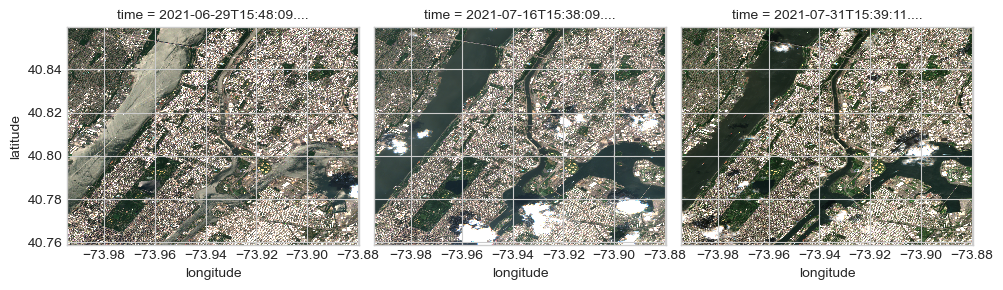

In [23]:
# Plot sample images from the time series
plot_data = data[["B04","B03","B02"]].to_array()
plot_data.plot.imshow(col='time', col_wrap=4, robust=True, vmin=0, vmax=2500)
plt.show()

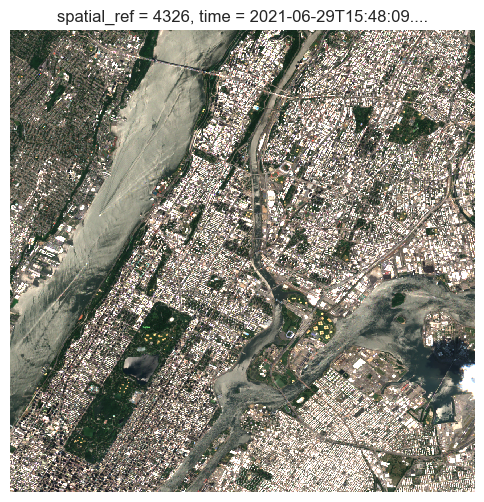

In [24]:
# Plot an RGB image for a single date
fig, ax = plt.subplots(figsize=(6,6))
plot_data.isel(time=0).plot.imshow(robust=True, ax=ax, vmin=0, vmax=2500)
ax.axis('off')
plt.show()

In [25]:
median = data.median(dim="time").compute()

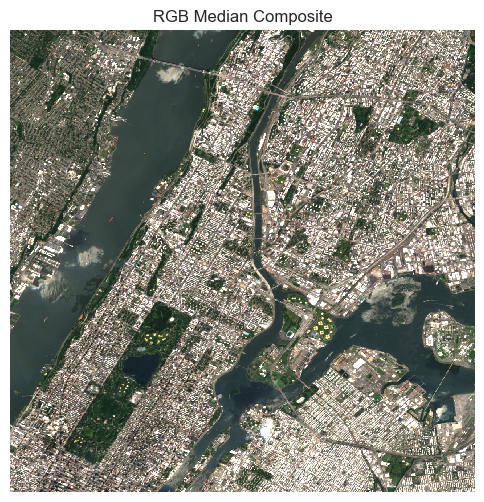

In [26]:
# Plot an RGB image for the median composite or mosaic
# Notice how this new image is void of clouds due to statistical filtering
fig, ax = plt.subplots(figsize=(6,6))
median[["B04", "B03", "B02"]].to_array().plot.imshow(robust=True, ax=ax, vmin=0, vmax=2500)
ax.set_title("RGB Median Composite")
ax.axis('off')
plt.show()

In [27]:
# Calculate NDVI for the median mosaic
ndvi_median = (median.B08-median.B04)/(median.B08+median.B04)

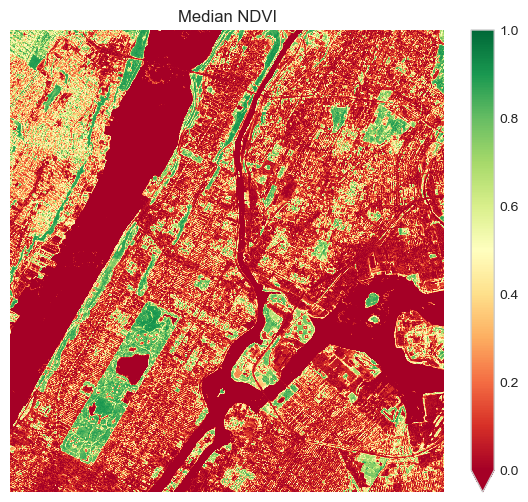

In [28]:
fig, ax = plt.subplots(figsize=(7,6))
ndvi_median.plot.imshow(vmin=0.0, vmax=1.0, cmap="RdYlGn")
plt.title("Median NDVI")
plt.axis('off')
plt.show()

In [29]:
# Calculate NDBI for the median mosaic
ndbi_median = (median.B11-median.B08)/(median.B11+median.B08)

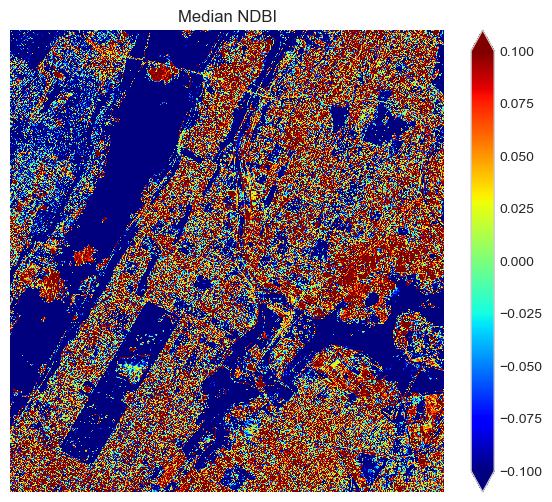

In [30]:
fig, ax = plt.subplots(figsize=(7,6))
ndbi_median.plot.imshow(vmin=-0.1, vmax=0.1, cmap="jet")
plt.title("Median NDBI")
plt.axis('off')
plt.show()

In [31]:
# Calculate NDWI for the median mosaic
ndwi_median = (median.B03-median.B08)/(median.B03+median.B08)

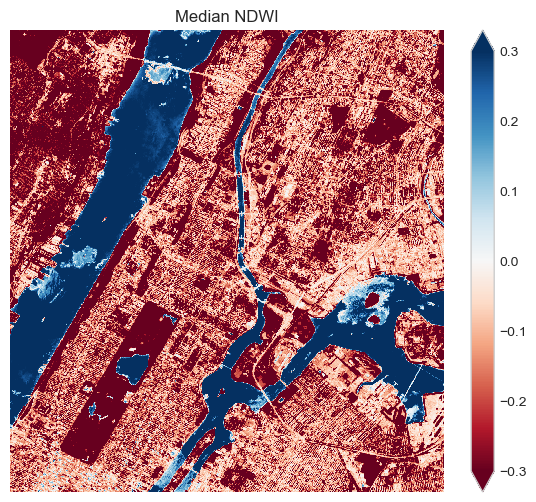

In [32]:
fig, ax = plt.subplots(figsize=(7,6))
ndwi_median.plot.imshow(vmin=-0.3, vmax=0.3, cmap="RdBu")
plt.title("Median NDWI")
plt.axis('off')
plt.show()

### 5.3 Extração de Dados do Landsat

In [36]:
stac = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace
)

data_coleta = "2021-07-24"
data_inicio = (datetime.strptime(data_coleta, "%Y-%m-%d") - timedelta(days=60)).strftime("%Y-%m-%d")
data_fim = (datetime.strptime(data_coleta, "%Y-%m-%d") + timedelta(days=60)).strftime("%Y-%m-%d")

landsat_items = stac.search(
    bbox=bbox, 
    datetime=f"{data_inicio}/{data_fim}",
    collections=["landsat-c2-l2"],
    query={"eo:cloud_cover": {"lt": 20},"platform": {"in": ["landsat-8"]}},
)

# Verificar número de itens encontrados
landsat_items = list(landsat_items.get_items())
print(f"Número de cenas Sentinel-2 encontradas: {len(landsat_items)}")

# Visualizar metadados e assets disponíveis da primeira cena
if len(landsat_items) > 0:
    print("Metadados da primeira cena Sentinel-2:")
    print(f"ID: {landsat_items[0].id}")
    print(f"Data: {landsat_items[0].properties['datetime']}")
    print(f"Cobertura de nuvens: {landsat_items[0].properties['eo:cloud_cover']}%")

Número de cenas Sentinel-2 encontradas: 8
Metadados da primeira cena Sentinel-2:
ID: LC08_L2SP_013032_20210920_02_T1
Data: 2021-09-20T15:33:59.233539Z
Cobertura de nuvens: 10.23%


In [37]:
signed_items = [planetary_computer.sign(item).to_dict() for item in landsat_items]

In [38]:
data1 = stac_load(
    landsat_items,
    bands=["red", "green", "blue", "nir08"],
    crs="EPSG:4326", # Latitude-Longitude
    resolution=scale, # Degrees
    chunks={"x": 2048, "y": 2048},
    dtype="uint16",
    patch_url=planetary_computer.sign,
    bbox=bbox
)

In [39]:
data2 = stac_load(
    landsat_items,
    bands=["lwir11"],
    crs="EPSG:4326", # Latitude-Longitude
    resolution=scale, # Degrees
    chunks={"x": 2048, "y": 2048},
    dtype="uint16",
    patch_url=planetary_computer.sign,
    bbox=bbox
)

In [40]:
# Persist the data in memory for faster operations
data1 = data1.persist()
data2 = data2.persist()

In [41]:
# Scale Factors for the RGB and NIR bands 
scale1 = 0.0000275 
offset1 = -0.2 
data1 = data1.astype(float) * scale1 + offset1

In [42]:
# Scale Factors for the Surface Temperature band
scale2 = 0.00341802 
offset2 = 149.0 
kelvin_celsius = 273.15 # convert from Kelvin to Celsius
data2 = data2.astype(float) * scale2 + offset2 - kelvin_celsius

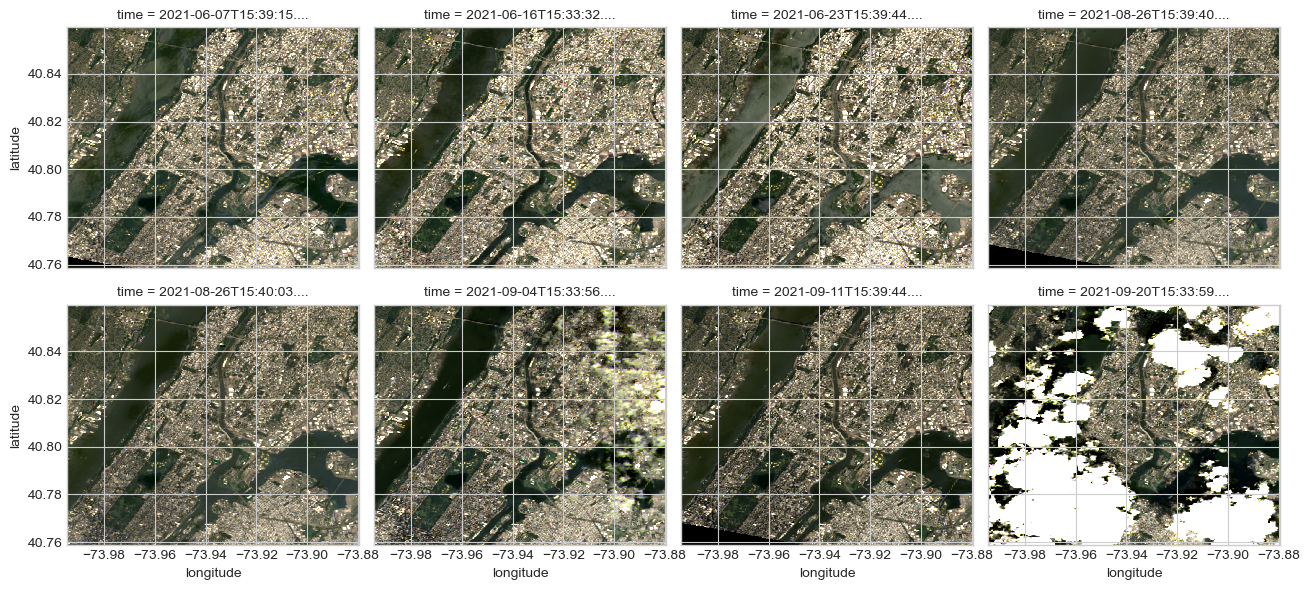

In [43]:
plot_data = data1[["red","green","blue"]].to_array()
plot_data.plot.imshow(col='time', col_wrap=4, robust=True, vmin=0, vmax=0.25)
plt.show()

In [44]:
# Pick one of the scenes above (numbering starts with 0)
scene = 0

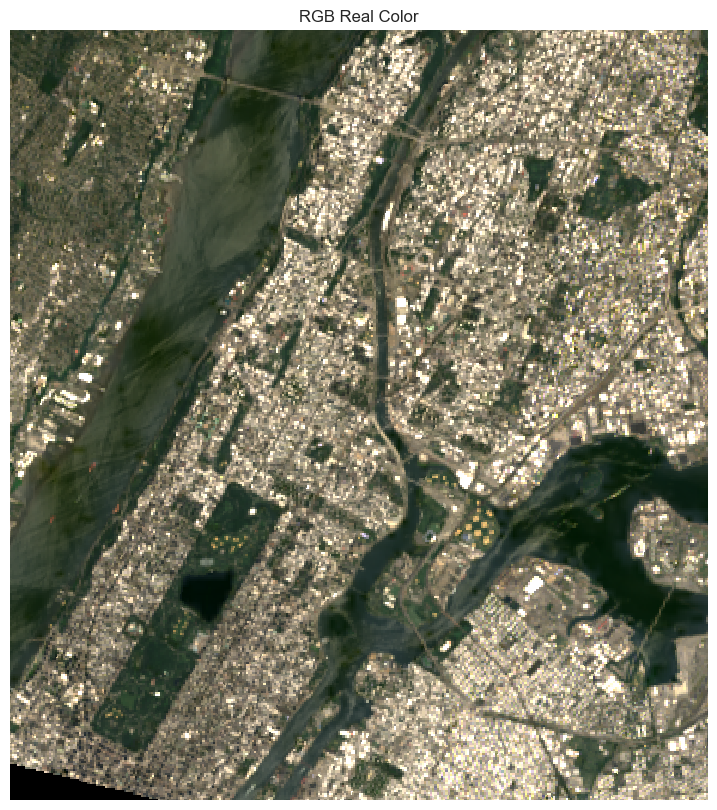

In [45]:
# Plot an RGB Real Color Image for a single date
fig, ax = plt.subplots(figsize=(9,10))
data1.isel(time=scene)[["red", "green", "blue"]].to_array().plot.imshow(robust=True, ax=ax, vmin=0.0, vmax=0.25)
ax.set_title("RGB Real Color")
ax.axis('off')
plt.show()

In [46]:
# Calculate NDVI for the median mosaic
ndvi_data = (data1.isel(time=scene).nir08-data1.isel(time=scene).red)/(data1.isel(time=scene).nir08+data1.isel(time=scene).red)

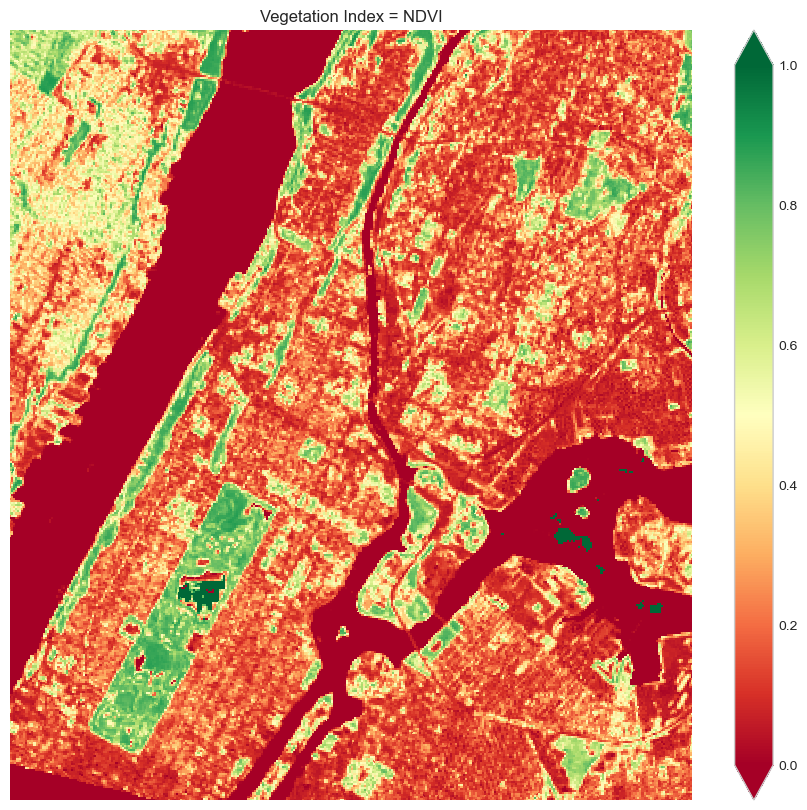

In [47]:
fig, ax = plt.subplots(figsize=(11,10))
ndvi_data.plot.imshow(vmin=0.0, vmax=1.0, cmap="RdYlGn")
plt.title("Vegetation Index = NDVI")
plt.axis('off')
plt.show()

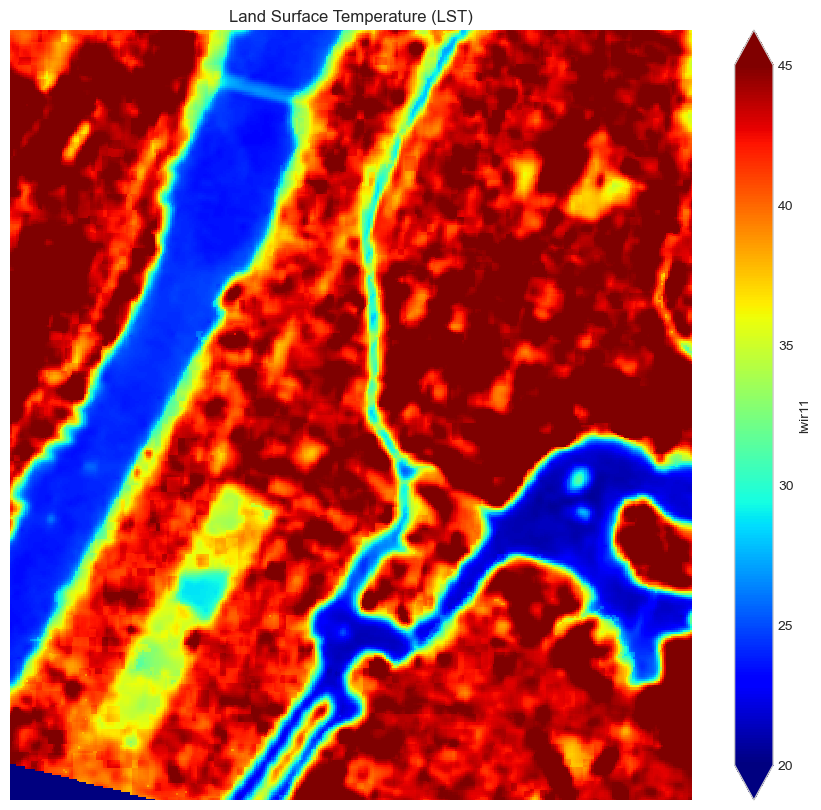

In [48]:
fig, ax = plt.subplots(figsize=(11,10))
data2.isel(time=scene).lwir11.plot.imshow(vmin=20.0, vmax=45.0, cmap="jet")
plt.title("Land Surface Temperature (LST)")
plt.axis('off')
plt.show()

In [52]:
import pandas as pd
import numpy as np
import xarray as xr
from tqdm.notebook import tqdm

# Função para extrair valores em coordenadas específicas
def extract_pixel_values(dataset, lon, lat):
    """
    Extrai o valor do pixel mais próximo das coordenadas fornecidas.
    
    Parameters:
    -----------
    dataset : xarray.Dataset ou xarray.DataArray
        Dataset ou DataArray do qual extrair valores
    lon : float
        Longitude do ponto
    lat : float
        Latitude do ponto
        
    Returns:
    --------
    float
        Valor do pixel na coordenada especificada
    """
    # Seleciona o pixel mais próximo
    try:
        # Com base nas informações obtidas, agora sabemos que as dimensões são 'latitude' e 'longitude'
        if isinstance(dataset, xr.Dataset):
            # Se for um Dataset, retorna um dicionário com valores para cada banda
            result = {}
            for var in dataset.data_vars:
                try:
                    # Sempre usar 'latitude' e 'longitude' como dimensões
                    point_data = dataset[var].sel(longitude=lon, latitude=lat, method="nearest")
                    
                    if "time" in point_data.dims:
                        result[var] = float(point_data.median().values)
                    else:
                        if hasattr(point_data, 'values'):
                            result[var] = float(point_data.values)
                        else:
                            result[var] = float(point_data)
                except Exception as e:
                    print(f"Erro ao processar variável {var}: {e}")
                    result[var] = np.nan
            return result
        else:
            # Se for um DataArray, retorna o valor diretamente
            try:
                # Sempre usar 'latitude' e 'longitude' como dimensões
                point_data = dataset.sel(longitude=lon, latitude=lat, method="nearest")
                
                if "time" in point_data.dims:
                    return float(point_data.median().values)
                else:
                    if hasattr(point_data, 'values'):
                        return float(point_data.values)
                    else:
                        return float(point_data)
            except Exception as e:
                print(f"Erro ao processar DataArray: {e}")
                return np.nan
    except Exception as e:
        print(f"Erro geral na extração: {e}")
        return np.nan

# Extrair valores para todos os pontos do conjunto de treinamento
print("Extraindo índices do Sentinel-2...")
feature_data = []

# Examinar as propriedades dos datasets para debugging
print("Dimensões do dataset Sentinel-2 (median):")
print(median.dims)
print("\nVariáveis do dataset Sentinel-2:")
print(list(median.data_vars))

print("\nDimensões do dataset NDVI Sentinel-2:")
print(ndvi_median.dims)

print("\nDimensões do dataset Landsat (data1):")
try:
    print(data1.dims)
    print("\nVariáveis do dataset Landsat:")
    print(list(data1.data_vars))
except Exception as e:
    print(f"Erro ao acessar informações do Landsat: {e}")

# Para cada ponto no conjunto de treinamento
for index, row in tqdm(df_train.iterrows(), total=len(df_train)):
    lon, lat = row['Longitude'], row['Latitude']
    
    # Dicionário para armazenar features deste ponto
    point_features = {
        'id': index,
        'Longitude': lon,
        'Latitude': lat,
        'UHI Index': row['UHI Index']
    }
    
    # Extrair bandas do Sentinel-2 com tratamento de erros mais robusto
    try:
        # Tenta extrair valores das bandas
        bands = extract_pixel_values(median, lon, lat)
        if isinstance(bands, dict):
            for band, value in bands.items():
                point_features[f'S2_{band}'] = value
        else:
            print(f"Resultado inesperado para bandas S2 no ponto {index}: {type(bands)}")
            # Se bands não for um dicionário, preenche com NaN
            for band in median.data_vars:
                point_features[f'S2_{band}'] = np.nan
                
        # Extrair índices calculados do Sentinel-2
        # Tratamento especial para índices que são DataArrays simples
        try:
            ndvi_value = ndvi_median.sel(longitude=lon, latitude=lat, method="nearest").values
            point_features['NDVI_S2'] = float(ndvi_value)
        except Exception as e:
            print(f"Erro ao extrair NDVI_S2 para ponto {index}: {e}")
            point_features['NDVI_S2'] = np.nan
            
        try:
            ndbi_value = ndbi_median.sel(longitude=lon, latitude=lat, method="nearest").values
            point_features['NDBI_S2'] = float(ndbi_value)
        except Exception as e:
            print(f"Erro ao extrair NDBI_S2 para ponto {index}: {e}")
            point_features['NDBI_S2'] = np.nan
            
        try:
            ndwi_value = ndwi_median.sel(longitude=lon, latitude=lat, method="nearest").values
            point_features['NDWI_S2'] = float(ndwi_value)
        except Exception as e:
            print(f"Erro ao extrair NDWI_S2 para ponto {index}: {e}")
            point_features['NDWI_S2'] = np.nan
        
    except Exception as e:
        print(f"Erro ao extrair dados Sentinel-2 para ponto {index}: {e}")
        # Preencher com NaN em caso de erro
        try:
            for band in median.data_vars:
                point_features[f'S2_{band}'] = np.nan
        except:
            print("Erro ao acessar data_vars do Sentinel-2")
        
        point_features['NDVI_S2'] = np.nan
        point_features['NDBI_S2'] = np.nan
        point_features['NDWI_S2'] = np.nan
    
    # Extrair dados do Landsat com tratamento de erros mais robusto
    try:
        # NDVI do Landsat - acesso direto usando dimensões conhecidas
        landsat_point = data1.isel(time=scene)
        
        # Extrai NIR e Red com acesso direto
        try:
            nir = landsat_point.nir08.sel(longitude=lon, latitude=lat, method="nearest").values
            nir = float(nir)
        except Exception as e:
            print(f"Erro ao extrair NIR para ponto {index}: {e}")
            nir = np.nan
            
        try:
            red = landsat_point.red.sel(longitude=lon, latitude=lat, method="nearest").values
            red = float(red)
        except Exception as e:
            print(f"Erro ao extrair RED para ponto {index}: {e}")
            red = np.nan
        
        # Calcula NDVI se possível
        if not (np.isnan(nir) or np.isnan(red)):
            ndvi_landsat = (nir - red) / (nir + red) if (nir + red) != 0 else np.nan
        else:
            ndvi_landsat = np.nan
            
        point_features['NDVI_LS'] = ndvi_landsat
        
        # LST (Temperatura de Superfície) do Landsat
        try:
            lst = data2.isel(time=scene).lwir11.sel(longitude=lon, latitude=lat, method="nearest").values
            point_features['LST_LS'] = float(lst)
        except Exception as e:
            print(f"Erro ao extrair LST para ponto {index}: {e}")
            point_features['LST_LS'] = np.nan
            
    except Exception as e:
        print(f"Erro ao extrair dados Landsat para ponto {index}: {e}")
        point_features['NDVI_LS'] = np.nan
        point_features['LST_LS'] = np.nan
    
    feature_data.append(point_features)

# Criar DataFrame com todas as features extraídas
df_features = pd.DataFrame(feature_data)

# Verificar quaisquer valores ausentes
print("\nVerificando valores ausentes nas features extraídas:")
print(df_features.isnull().sum())

# Salvar o conjunto de dados completo com features
df_features.to_csv('dataset/training_with_satellite_features.csv', index=False)
print("\nDataset completo salvo em 'dataset/training_with_satellite_features.csv'")

# Visualizar as primeiras linhas do dataset com as features
print("\nPrimeiras linhas do dataset com features:")
df_features.head()

# Calcular correlações entre índices e UHI
print("\nCorrelações entre índices de satélite e UHI Index:")
correlations = df_features[[
    'UHI Index', 'NDVI_S2', 'NDBI_S2', 'NDWI_S2', 'NDVI_LS', 'LST_LS'
]].corr()['UHI Index'].sort_values(ascending=False)
print(correlations)



Extraindo índices do Sentinel-2...
Dimensões do dataset Sentinel-2 (median):
FrozenMappingWarningOnValuesAccess({'latitude': 1122, 'longitude': 1281})

Variáveis do dataset Sentinel-2:
['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12']

Dimensões do dataset NDVI Sentinel-2:
('latitude', 'longitude')

Dimensões do dataset Landsat (data1):
FrozenMappingWarningOnValuesAccess({'latitude': 1122, 'longitude': 1281, 'time': 8})

Variáveis do dataset Landsat:
['red', 'green', 'blue', 'nir08']


  0%|          | 0/11229 [00:00<?, ?it/s]


Verificando valores ausentes nas features extraídas:
id           0
Longitude    0
Latitude     0
UHI Index    0
S2_B01       0
S2_B02       0
S2_B03       0
S2_B04       0
S2_B05       0
S2_B06       0
S2_B07       0
S2_B08       0
S2_B8A       0
S2_B11       0
S2_B12       0
NDVI_S2      0
NDBI_S2      0
NDWI_S2      0
NDVI_LS      0
LST_LS       0
dtype: int64

Dataset completo salvo em 'dataset/training_with_satellite_features.csv'

Primeiras linhas do dataset com features:

Correlações entre índices de satélite e UHI Index:
UHI Index    1.000000
LST_LS       0.419292
NDWI_S2      0.236544
NDBI_S2      0.211681
NDVI_S2     -0.231786
NDVI_LS     -0.269039
Name: UHI Index, dtype: float64


In [58]:
import pandas as pd
import numpy as np
import xarray as xr
from tqdm.notebook import tqdm

# Carregar arquivo de submissão
submission_df = pd.read_csv('dataset/submission_template.csv')
print(f"Arquivo de submissão carregado com {submission_df.shape[0]} pontos")
print(submission_df)

# Função para extrair valores em coordenadas específicas (versão otimizada)
def extract_pixel_values_at_coords(dataset, lon, lat):
    try:
        # Com base nas informações obtidas, agora sabemos que as dimensões são 'latitude' e 'longitude'
        if isinstance(dataset, xr.Dataset):
            # Se for um Dataset, retorna um dicionário com valores para cada banda
            result = {}
            for var in dataset.data_vars:
                try:
                    # Sempre usar 'latitude' e 'longitude' como dimensões
                    point_data = dataset[var].sel(longitude=lon, latitude=lat, method="nearest")
                    
                    if "time" in point_data.dims:
                        result[var] = float(point_data.median().values)
                    else:
                        if hasattr(point_data, 'values'):
                            result[var] = float(point_data.values)
                        else:
                            result[var] = float(point_data)
                except Exception as e:
                    print(f"Erro ao processar variável {var}: {e}")
                    result[var] = np.nan
            return result
        else:
            # Se for um DataArray, retorna o valor diretamente
            try:
                # Sempre usar 'latitude' e 'longitude' como dimensões
                point_data = dataset.sel(longitude=lon, latitude=lat, method="nearest")
                
                if "time" in point_data.dims:
                    return float(point_data.median().values)
                else:
                    if hasattr(point_data, 'values'):
                        return float(point_data.values)
                    else:
                        return float(point_data)
            except Exception as e:
                print(f"Erro ao processar DataArray: {e}")
                return np.nan
    except Exception as e:
        print(f"Erro geral na extração: {e}")
        return np.nan

# Extrair features para cada ponto do arquivo de submissão
print("Extraindo índices para os pontos de submissão...")
feature_data = []

# Para cada ponto no conjunto de submissão
for index, row in tqdm(submission_df.iterrows(), total=len(submission_df)):
    lon, lat = row['Longitude'], row['Latitude']
    
    # Dicionário para armazenar features deste ponto
    point_features = {
        'Longitude': lon,
        'Latitude': lat
    }
    
    # Extrair bandas do Sentinel-2
    try:
        # Extrair bandas diretamente
        bands = extract_pixel_values_at_coords(median, lon, lat)
        if isinstance(bands, dict):
            for band, value in bands.items():
                point_features[f'S2_{band}'] = value
        else:
            print(f"Resultado inesperado para bandas S2 no ponto {index}: {type(bands)}")
            
        # Extrair índices do Sentinel-2
        try:
            ndvi_value = ndvi_median.sel(longitude=lon, latitude=lat, method="nearest").values
            point_features['NDVI_S2'] = float(ndvi_value)
        except Exception as e:
            print(f"Erro ao extrair NDVI_S2 para ponto {index}: {e}")
            point_features['NDVI_S2'] = np.nan
            
        try:
            ndbi_value = ndbi_median.sel(longitude=lon, latitude=lat, method="nearest").values
            point_features['NDBI_S2'] = float(ndbi_value)
        except Exception as e:
            print(f"Erro ao extrair NDBI_S2 para ponto {index}: {e}")
            point_features['NDBI_S2'] = np.nan
            
        try:
            ndwi_value = ndwi_median.sel(longitude=lon, latitude=lat, method="nearest").values
            point_features['NDWI_S2'] = float(ndwi_value)
        except Exception as e:
            print(f"Erro ao extrair NDWI_S2 para ponto {index}: {e}")
            point_features['NDWI_S2'] = np.nan
            
    except Exception as e:
        print(f"Erro ao extrair dados Sentinel-2 para ponto {index}: {e}")
        # Preencher com NaN em caso de erro
        try:
            for band in median.data_vars:
                point_features[f'S2_{band}'] = np.nan
        except:
            print("Erro ao acessar data_vars do Sentinel-2")
        
        point_features['NDVI_S2'] = np.nan
        point_features['NDBI_S2'] = np.nan
        point_features['NDWI_S2'] = np.nan
    
    # Extrair dados do Landsat
    try:
        # NDVI do Landsat - acesso direto usando dimensões conhecidas
        landsat_point = data1.isel(time=scene)
        
        # Extrai NIR e Red com acesso direto
        try:
            nir = landsat_point.nir08.sel(longitude=lon, latitude=lat, method="nearest").values
            nir = float(nir)
        except Exception as e:
            print(f"Erro ao extrair NIR para ponto {index}: {e}")
            nir = np.nan
            
        try:
            red = landsat_point.red.sel(longitude=lon, latitude=lat, method="nearest").values
            red = float(red)
        except Exception as e:
            print(f"Erro ao extrair RED para ponto {index}: {e}")
            red = np.nan
        
        # Calcula NDVI se possível
        if not (np.isnan(nir) or np.isnan(red)):
            ndvi_landsat = (nir - red) / (nir + red) if (nir + red) != 0 else np.nan
        else:
            ndvi_landsat = np.nan
            
        point_features['NDVI_LS'] = ndvi_landsat
        
        # LST (Temperatura de Superfície) do Landsat
        try:
            lst = data2.isel(time=scene).lwir11.sel(longitude=lon, latitude=lat, method="nearest").values
            point_features['LST_LS'] = float(lst)
        except Exception as e:
            print(f"Erro ao extrair LST para ponto {index}: {e}")
            point_features['LST_LS'] = np.nan
            
    except Exception as e:
        print(f"Erro ao extrair dados Landsat para ponto {index}: {e}")
        point_features['NDVI_LS'] = np.nan
        point_features['LST_LS'] = np.nan
    
    feature_data.append(point_features)

# Criar DataFrame com todas as features extraídas
submission_features = pd.DataFrame(feature_data)

# Verificar quaisquer valores ausentes
print("\nVerificando valores ausentes nas features extraídas:")
print(submission_features.isnull().sum())

# Salvar as features extraídas
submission_features.to_csv('dataset/submission_features.csv', index=False)
print("\nFeatures de submissão salvas em 'dataset/submission_features.csv'")

# Exibir as primeiras linhas das features extraídas
print("\nFeatures extraídas:")
print(submission_features.head())

Arquivo de submissão carregado com 1040 pontos
      Longitude   Latitude  UHI Index
0    -73.971665  40.788763        NaN
1    -73.971928  40.788875        NaN
2    -73.967080  40.789080        NaN
3    -73.972550  40.789082        NaN
4    -73.969697  40.787953        NaN
...         ...        ...        ...
1035 -73.919388  40.813803        NaN
1036 -73.931033  40.833178        NaN
1037 -73.934647  40.854542        NaN
1038 -73.917223  40.815413        NaN
1039 -73.911645  40.804402        NaN

[1040 rows x 3 columns]
Extraindo índices para os pontos de submissão...


  0%|          | 0/1040 [00:00<?, ?it/s]


Verificando valores ausentes nas features extraídas:
Longitude    0
Latitude     0
S2_B01       0
S2_B02       0
S2_B03       0
S2_B04       0
S2_B05       0
S2_B06       0
S2_B07       0
S2_B08       0
S2_B8A       0
S2_B11       0
S2_B12       0
NDVI_S2      0
NDBI_S2      0
NDWI_S2      0
NDVI_LS      0
LST_LS       0
dtype: int64

Features de submissão salvas em 'dataset/submission_features.csv'

Features extraídas:
   Longitude   Latitude  S2_B01  S2_B02  S2_B03  S2_B04  S2_B05  S2_B06  S2_B07  S2_B08  S2_B8A  S2_B11  S2_B12   NDVI_S2   NDBI_S2   NDWI_S2   NDVI_LS     LST_LS
0 -73.971665  40.788763   786.0   511.0   557.0   560.0  1112.0  2163.0  2587.0  2282.0  2627.0  1713.0  1180.0  0.605911 -0.142428 -0.607608  0.581530  42.591270
1 -73.971928  40.788875  1163.0   628.0   845.0   722.0  1245.0  2582.0  2959.0  3002.0  2945.0  2152.0  1421.0  0.612245 -0.164920 -0.560697  0.509596  42.755335
2 -73.967080  40.789080  1049.0   841.0   939.0  1008.0   938.0  1268.0  1599.0  1402.

In [60]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# Carregar dados de treinamento
df_train = pd.read_csv('dataset/training_with_satellite_features.csv')

# Preencher valores nulos com a mediana
for col in df_train.columns:
    if df_train[col].dtype != 'object' and col != 'id':
        df_train[col] = df_train[col].fillna(df_train[col].median())

# Selecionar features e target (removendo latitude e longitude)
X_train = df_train.drop(['id', 'UHI Index', 'Latitude', 'Longitude'], axis=1)
y_train = df_train['UHI Index']

print("Features usadas no modelo:")
print(X_train.columns.tolist())

# Treinar modelo com todos os dados
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Carregar features extraídas para submissão
submission_features = pd.read_csv('dataset/submission_features.csv')

# Verificar se temos as mesmas colunas
missing_cols = set(X_train.columns) - set(submission_features.columns)
extra_cols = set(submission_features.columns) - set(X_train.columns) - set(['Latitude', 'Longitude'])

if missing_cols:
    print(f"Atenção: Colunas ausentes nas features de submissão: {missing_cols}")
    # Adicionar colunas ausentes com valores nulos
    for col in missing_cols:
        submission_features[col] = np.nan

# Preencher valores nulos com a mediana dos dados de treinamento
for col in X_train.columns:
    if col in submission_features.columns and submission_features[col].isnull().any():
        median_val = df_train[col].median()
        print(f"Preenchendo {submission_features[col].isnull().sum()} valores nulos em '{col}' com mediana: {median_val}")
        submission_features[col] = submission_features[col].fillna(median_val)

# Selecionar apenas as colunas necessárias para previsão
X_submission = submission_features[X_train.columns]

# Fazer previsões
predictions = model.predict(X_submission)

# Adicionar previsões ao dataframe original de submissão
submission_df = pd.read_csv('dataset/submission_template.csv')
submission_df['UHI Index'] = predictions

# Exibir resultados
print("\nPrevisões para o arquivo de submissão:")
print(submission_df)

# Salvar arquivo de submissão
submission_df.to_csv('submission_final.csv', index=False)
print("\nArquivo de submissão com previsões salvo como 'submission_final.csv'")

Features usadas no modelo:
['S2_B01', 'S2_B02', 'S2_B03', 'S2_B04', 'S2_B05', 'S2_B06', 'S2_B07', 'S2_B08', 'S2_B8A', 'S2_B11', 'S2_B12', 'NDVI_S2', 'NDBI_S2', 'NDWI_S2', 'NDVI_LS', 'LST_LS']

Previsões para o arquivo de submissão:
      Longitude   Latitude  UHI Index
0    -73.971665  40.788763   0.969054
1    -73.971928  40.788875   0.975914
2    -73.967080  40.789080   0.982860
3    -73.972550  40.789082   0.985043
4    -73.969697  40.787953   0.962425
...         ...        ...        ...
1035 -73.919388  40.813803   1.016435
1036 -73.931033  40.833178   1.028930
1037 -73.934647  40.854542   1.013339
1038 -73.917223  40.815413   1.021696
1039 -73.911645  40.804402   1.031186

[1040 rows x 3 columns]

Arquivo de submissão com previsões salvo como 'submission_final.csv'
